In [2]:
import os
import glob
import getpass
import pandas as pd
import mysql.connector

# ------------------------------------------------------------------
# 1) Sirf FOLDER apne hisab se set karein (jahan CSV files rakhi hain)
# ------------------------------------------------------------------
FOLDER = r"C:/Users/Aliab/Desktop/python_and_sql/E-Commerce Sales Performance Analysis"

# (csv ka naam, table ka naam, primary key, date columns)
FILES = [
    ("Customers.csv",    "Customers",    "CustomerID",    ["SignupDate"]),
    ("Products.csv",     "Products",     "ProductID",     []),
    ("Transactions.csv", "Transactions", "TransactionID", ["TransactionDate"]),
]

# ------------------------------------------------------------------
# 2) Folder aur files check karo
# ------------------------------------------------------------------
if not os.path.isdir(FOLDER):
    raise SystemExit(f"Folder nahi mila: {FOLDER}\nFile Explorer se sahi path copy karke FOLDER mein daalein.")

def find_csv(folder, name):
    exact = os.path.join(folder, name)
    if os.path.isfile(exact):
        return exact
    for f in glob.glob(os.path.join(folder, "*.csv")):
        if os.path.basename(f).lower() == name.lower():
            return f
    stem = os.path.splitext(name)[0].lower()
    for f in glob.glob(os.path.join(folder, "*.csv")):
        base = os.path.basename(f).lower()
        if base.startswith(stem) and "copy" not in base:
            return f
    return None

paths, missing = {}, []
for csv_file, table, pk, date_cols in FILES:
    p = find_csv(FOLDER, csv_file)
    if p is None:
        missing.append(csv_file)
    else:
        paths[csv_file] = p

if missing:
    print("Ye files nahi mili:", missing)
    print("Folder mein ye files hain:")
    for f in os.listdir(FOLDER):
        print("  ", repr(f))
    raise SystemExit("FOLDER ya FILES theek karke dobara chalayein.")

# ------------------------------------------------------------------
# 3) MySQL connection (password type karein, code mein save nahi hota)
# ------------------------------------------------------------------
password = getpass.getpass("MySQL password: ")

conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password=password,
    database="ecommerce",
)
cursor = conn.cursor()

# ------------------------------------------------------------------
# 4) Data types
# ------------------------------------------------------------------
def sql_type(col, dtype, pk):
    if col == pk:
        return "VARCHAR(50)"
    if pd.api.types.is_integer_dtype(dtype):
        return "INT"
    if pd.api.types.is_float_dtype(dtype):
        return "DOUBLE"
    if pd.api.types.is_datetime64_any_dtype(dtype):
        return "DATETIME"
    return "VARCHAR(255)"

# ------------------------------------------------------------------
# 5) Purane tables hata kar fresh load (duplicates nahi aayenge)
# ------------------------------------------------------------------
cursor.execute("DROP TABLE IF EXISTS `Online_transactions`")   # purani unused table

for csv_file, table, pk, date_cols in FILES:
    df = pd.read_csv(paths[csv_file], parse_dates=date_cols)
    before = len(df)
    df = df.drop_duplicates()
    df.columns = [c.strip().replace(" ", "_").replace("-", "_").replace(".", "_") for c in df.columns]

    cols = ", ".join(f"`{c}` {sql_type(c, df[c].dtype, pk)}" for c in df.columns)

    cursor.execute(f"DROP TABLE IF EXISTS `{table}`")           # <- asli fix
    cursor.execute(f"CREATE TABLE `{table}` ({cols}, PRIMARY KEY (`{pk}`))")

    rows = df.astype(object).where(df.notna(), None).values.tolist()
    col_names = ", ".join(f"`{c}`" for c in df.columns)
    placeholders = ", ".join(["%s"] * len(df.columns))
    cursor.executemany(f"INSERT INTO `{table}` ({col_names}) VALUES ({placeholders})", rows)
    conn.commit()
    print(f"{table}: {len(df)} rows loaded (CSV mein {before} rows thi)")

# ------------------------------------------------------------------
# 6) Verify
# ------------------------------------------------------------------
cursor.execute("SELECT COUNT(*), ROUND(SUM(TotalValue), 2), ROUND(AVG(TotalValue), 2) FROM Transactions")
n, total, avg = cursor.fetchone()
print(f"\nTransactions: {n} | Total revenue: {total} | Avg transaction: {avg}")

cursor.execute("""
    SELECT ROUND(SUM(t.TotalValue), 2)
    FROM Transactions t
    JOIN Products p  ON p.ProductID  = t.ProductID
    JOIN Customers c ON c.CustomerID = t.CustomerID
""")
print("Revenue after joins:", cursor.fetchone()[0], "(upar wale total ke barabar hona chahiye)")

conn.close()

MySQL password:  ········


Customers: 200 rows loaded (CSV mein 200 rows thi)
Products: 100 rows loaded (CSV mein 100 rows thi)
Transactions: 1000 rows loaded (CSV mein 1000 rows thi)

Transactions: 1000 | Total revenue: 689995.56 | Avg transaction: 690.0
Revenue after joins: 689995.56 (upar wale total ke barabar hona chahiye)


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mysql.connector
import warnings
warnings.filterwarnings('ignore')


db = mysql.connector.connect(host = "localhost", 
                             username = "root", 
                             password = "24ds09", 
                             database = "ecommerce")

cur = db.cursor()

## What is the total revenue generated?

In [4]:
query = 'select round(sum(TotalValue), 2) from transactions'

cur.execute(query)

data = cur.fetchall()

data

[(689995.56,)]

### How many total transactions are there?

In [5]:
query = 'select count(TransactionID) from transactions'

cur.execute(query)

data = cur.fetchall()

"Total number of transactions: ",data

('Total number of transactions: ', [(1000,)])

###  What is the total quantity of products sold? 

In [6]:
query = 'select sum(Quantity) from transactions'

cur.execute(query)

data = cur.fetchall()

data

[(Decimal('2537'),)]

### What is the average transactions value?

In [7]:
query = 'select round(avg(TotalValue),2) from transactions '

cur.execute(query)

data = cur.fetchall()

data

[(690.0,)]

### Which region has the Highest number of Customers?

In [8]:
query = """ select Region, count(CustomerID) as TotalCustomers from customers
group by Region order by TotalCustomers desc limit 1"""

cur.execute(query)

data = cur.fetchall()

data

[('South America', 59)]

### What are the top 10 customers by total spending, and how do they compare visually?

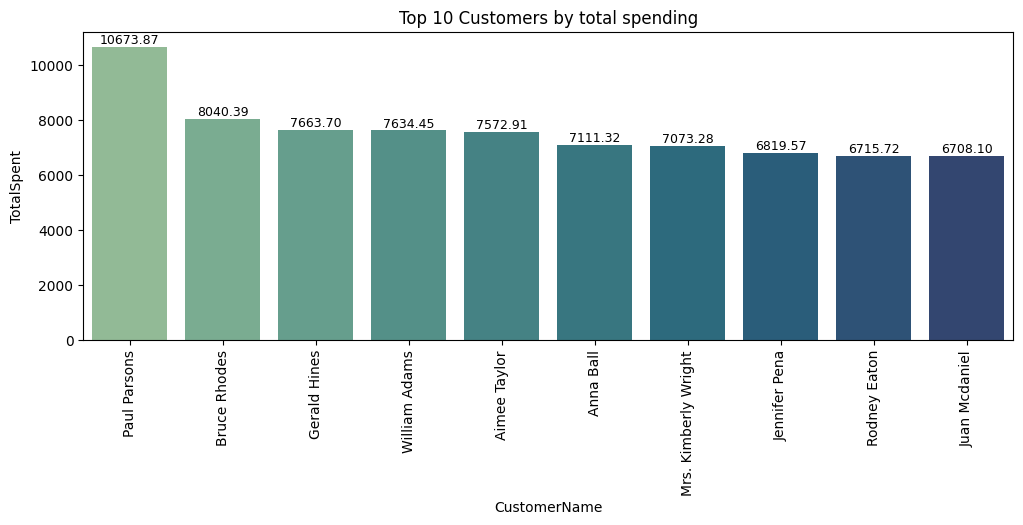

In [9]:
query = """ select c.CustomerName, round(sum(t.TotalValue), 2) as TotalSpent from transactions as t
join customers as c
on c.CustomerID = t.CustomerID
group by CustomerName order by TotalSpent desc limit 10
 """

cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(data, columns=['CustomerName','TotalSpent'])

plt.figure(figsize=(12,4))
ax = sns.barplot(df, x='CustomerName', y='TotalSpent', palette='crest')
plt.title('Top 10 Customers by total spending')
plt.xticks(rotation = 90)

for container in ax.containers:
    ax.bar_label(container, size=9, fmt='%.2f')

plt.show()    

### What are the top 10 products by revenue?

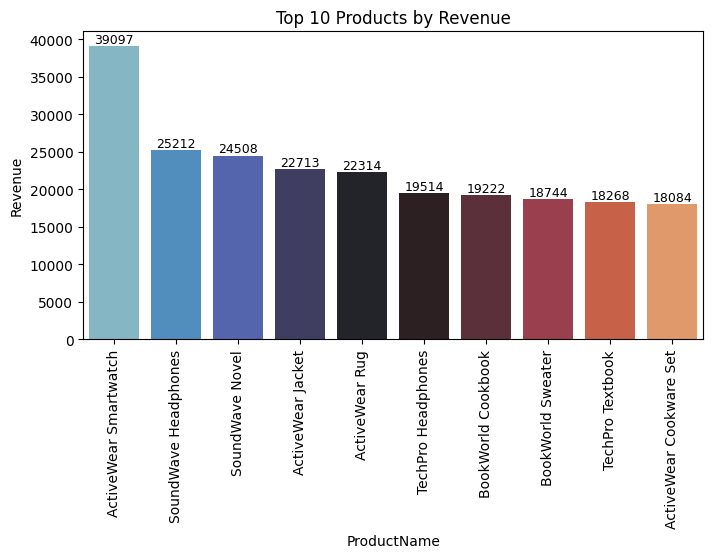

In [10]:
query = """ select p.ProductName, round(sum(t.TotalValue), 2) as Revenue from transactions as t
join products as p
on t.ProductID = p.ProductID 
group by p.ProductName order by Revenue desc limit 10
"""

cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(data, columns=['ProductName', 'Revenue'])

plt.figure(figsize=(8,4))
ax = sns.barplot(df, x='ProductName', y='Revenue', palette='icefire')
plt.title('Top 10 Products by Revenue')
plt.xticks(rotation = 90)

for container in ax.containers:
    ax.bar_label(container, size=9, fmt='%.0f')

plt.show()    

### What is the average transaction value by each region?

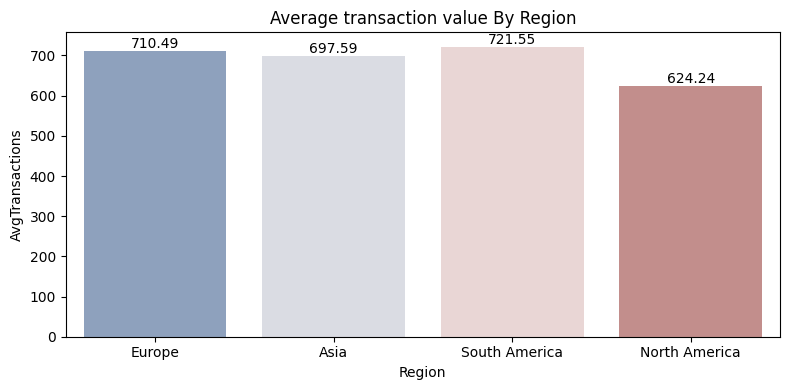

In [11]:
query = """ select c.Region, round(avg(t.TotalValue),2) as AvgTransactions from customers as c 
join transactions as t 
on c.CustomerID = t.CustomerID 
group by c.Region """

cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(data, columns=['Region', 'AvgTransactions'])

plt.figure(figsize=(8,4))
ax = sns.barplot(df, x='Region', y='AvgTransactions', palette='vlag')
plt.title('Average transaction value By Region')

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show() 

### What is the total revenue generated by each product category?

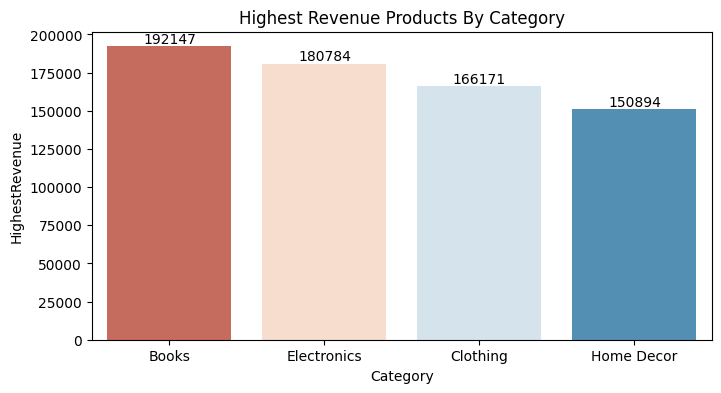

In [12]:
query = """ select p.Category, round(sum(t.TotalValue), 2) as HighestRevenue from products as p
join transactions as t
on p.ProductID = t.ProductID
group by p.Category order by HighestRevenue desc """

cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(data, columns=['Category', 'HighestRevenue'])

plt.figure(figsize=(8,4))
ax = sns.barplot(df, x='Category', y='HighestRevenue', palette='RdBu')
plt.title('Highest Revenue Products By Category')

for container in ax.containers:
    ax.bar_label(container)

plt.show()    

### What is the Quantity Sold by each product category?

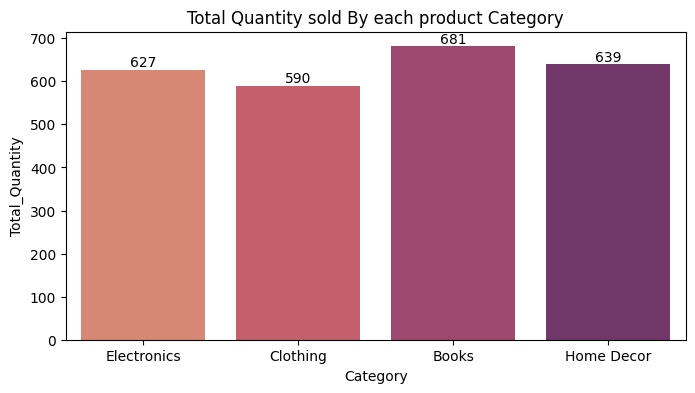

In [13]:
query = """ select p.Category, sum(t.Quantity) as Total_Quantity from products p
join transactions t
on p.ProductID = t.ProductID 
group by p.Category """

cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(data, columns=['Category', 'Total_Quantity'])

plt.figure(figsize=(8,4))
ax = sns.barplot(df, x='Category', y='Total_Quantity', palette='flare')
plt.title('Total Quantity sold By each product Category')

for container in ax.containers:
    ax.bar_label(container)

plt.show() 

### How many unique customers purchased each product category?

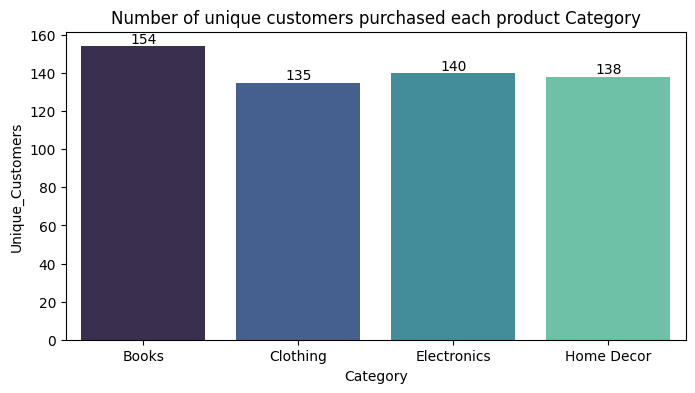

In [14]:
query = """ select p.Category, count(distinct(t.CustomerID)) as cutomers from products p
join transactions t
on t.ProductID = p.ProductID
group by p.Category """

cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(data, columns=['Category', 'Unique_Customers'])

plt.figure(figsize=(8,4))
ax = sns.barplot(df, x='Category', y='Unique_Customers', palette='mako')
plt.title('Number of unique customers purchased each product Category')

for container in ax.containers:
    ax.bar_label(container)

plt.show() 

### How many unique products has eash customer purchased?

In [15]:
query = """ select c.CustomerName, count(distinct(t.ProductID)) as UniqueProducts from transactions t
join customers c 
on c.CustomerID = t.CustomerID
group by CustomerName order by UniqueProducts desc """

cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(data, columns=['CustomerName', 'UniqueProductsPurchased'])

df

,CustomerName,UniqueProductsPurchased
0,Abigail Jones,10
1,David Li,10
2,Gerald Hines,10
3,Matthew Johnson,10
4,Paul Parsons,10
...,...,...
194,Mr. Manuel Conway,1
195,Robert Jones,1
196,Tina Ford,1
197,Tyler Holt,1


### What is the total spending and average transaction value for each customer?

In [16]:
query = """ select c.CustomerName, round(sum(t.TotalValue), 2), round(avg(t.TotalValue), 2) from transactions t
join customers c
on c.CustomerID = t.CustomerID
group by CustomerName """

cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(data, columns=['CustomerName', 'TotalSpending', 'AverageTransaction'])

df

,CustomerName,TotalSpending,AverageTransaction
0,Andrea Jenkins,1979.28,494.82
1,Jacqueline Zamora,3015.95,753.99
2,Jennifer Pena,6819.57,852.45
3,Kathleen Rodriguez,5354.88,669.36
4,Angela Williams,580.34,580.34
...,...,...,...
194,Tina Duran,1157.48,578.74
195,Julia Palmer,995.52,995.52
196,Paul Carter,2556.22,1278.11
197,David Gonzalez,1007.52,1007.52


### What are the top 3 products by revenue within each category?

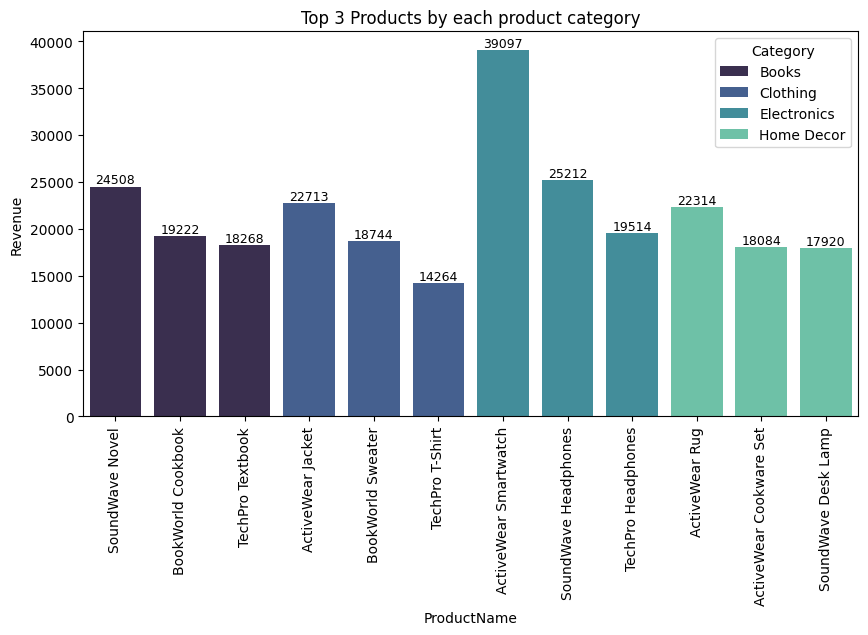

In [17]:
query = """ select * from (select p.Category, p.ProductName, round(sum(t.TotalValue)) as total_sales,
row_number() over(
partition by p.Category
order by sum(t.TotalValue) desc)
as rn
from products p
join transactions t
on p.ProductID = t.ProductID
group by p.Category,p.ProductName
) x
where rn <=3 """

cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(data, columns=['Category', 'ProductName', 'Revenue', 'RowNumber'])

plt.figure(figsize=(10,5))
ax = sns.barplot(df, x='ProductName', y='Revenue', hue='Category', palette='mako')
plt.title('Top 3 Products by each product category')
plt.xticks(rotation = 90)

for container in ax.containers:
    ax.bar_label(container, size=9, fmt='%.0f')

plt.show()    

### Which product category is most popular in each region?

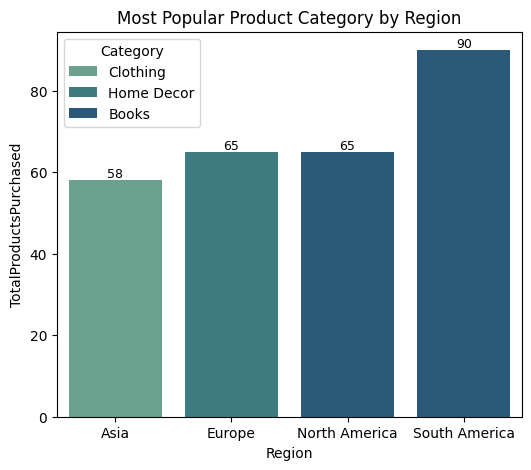

In [18]:
query = """ select * from (select c.Region, p.Category, count(t.ProductID) as TotalProductsPurchased,
row_number() over(
partition by c.Region
order by count(t.ProductID) desc
) as rn
from transactions t
join customers c
on c.CustomerID = t.CustomerID
join products p
on p.ProductID = t.ProductID
group by Region, Category
) x
where rn <= 1 """

cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(data, columns=['Region', 'Category', 'TotalProductsPurchased', 'RowNumber'])

plt.figure(figsize=(6,5))
ax = sns.barplot(df, x='Region', y='TotalProductsPurchased', hue='Category', palette='crest')
plt.title('Most Popular Product Category by Region')

for container in ax.containers:
    ax.bar_label(container, size=9, fmt='%.0f')

plt.show()    

### Which region generates the highest revenue for each product category?

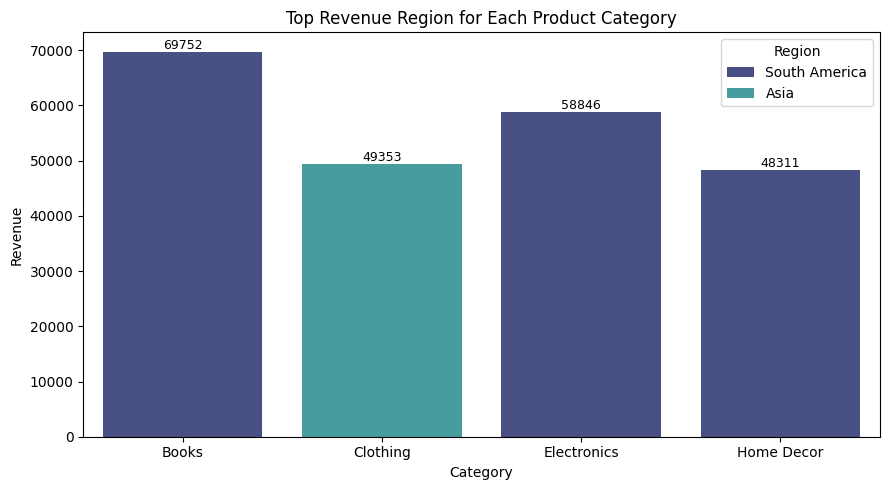

In [19]:
query = """
select Category, Region, Revenue from (
    select p.Category, c.Region,
           round(sum(t.TotalValue)) as Revenue,
           row_number() over (
               partition by p.Category
               order by sum(t.TotalValue) desc
           ) as rn
    from transactions t
    join customers c on c.CustomerID = t.CustomerID
    join products p on p.ProductID = t.ProductID
    group by p.Category, c.Region
) x
where rn = 1
"""

cur.execute(query)
data = cur.fetchall()

df = pd.DataFrame(data, columns=['Category', 'Region', 'Revenue'])

plt.figure(figsize=(9, 5))
ax = sns.barplot(df, x='Category', y='Revenue', hue='Region', palette='mako', dodge=False)
plt.title('Top Revenue Region for Each Product Category')

for container in ax.containers:
    ax.bar_label(container, size=9, fmt='%.0f')

plt.tight_layout()
plt.show()

### What percentage of total revenue comes from each product category?

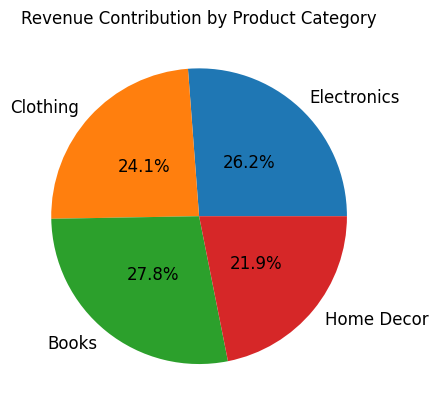

In [20]:
query = """ select p.Category, round(sum(t.TotalValue) * 100 / sum(sum(t.TotalValue)) over(),2) as percentage from transactions t
join products p 
on p.ProductID = t.ProductID
group by p.Category 
"""
cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(data, columns=['Category', 'Percentage'])

ax = plt.pie(df['Percentage'], labels=df['Category'], autopct='%.1f%%', textprops={'fontsize':12}, pctdistance=0.5)
plt.title('Revenue Contribution by Product Category')

plt.show()    

### What is the monthly revenue trend?

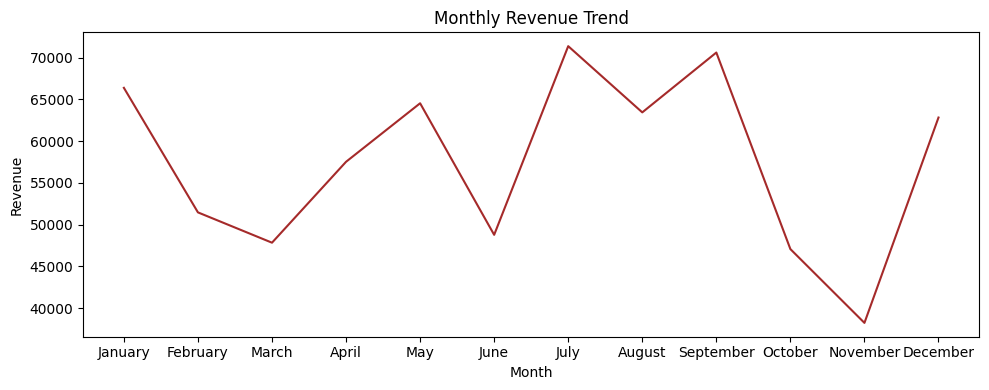

In [21]:
query = """ select monthname(TransactionDate) as Month, round(sum(TotalValue),2) as Revenue from transactions
group by Month, month(TransactionDate)
order by month(TransactionDate)""" 

cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(data, columns=['Month', 'Revenue'])

plt.figure(figsize=(10,4))
ax = sns.lineplot(df, x='Month', y='Revenue', color='brown')
plt.title('Monthly Revenue Trend')

plt.tight_layout()
plt.show()

### How many transactions occur each month?

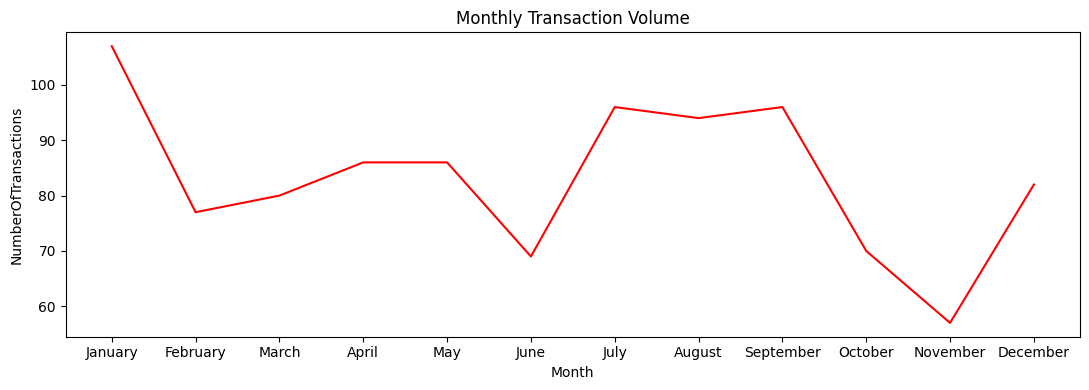

In [22]:
query = """ select monthname(TransactionDate) as Month,
       count(TransactionID) as NumberOfTransactions
from transactions
group by month(TransactionDate), monthname(TransactionDate)
order by month(TransactionDate);
"""
cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(data, columns=['Month', 'NumberOfTransactions'])

plt.figure(figsize=(11,4))
ax = sns.lineplot(df, x='Month', y='NumberOfTransactions', color='r')
plt.title('Monthly Transaction Volume')

plt.tight_layout()
plt.show()

### Which month generated the highest revenue?

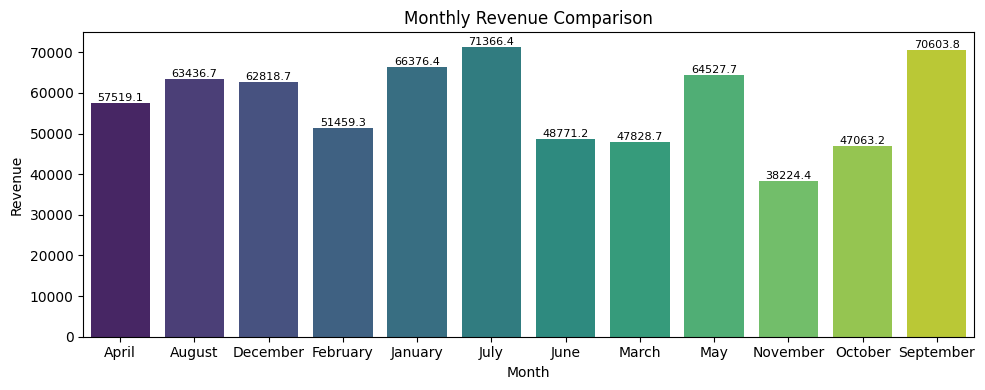

In [23]:
query = """ select monthname(TransactionDate) as Month, round(sum(TotalValue),2) as Revenue from transactions
group by Month
order by Month asc""" 

cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(data, columns=['Month', 'Revenue'])

plt.figure(figsize=(10,4))
ax = sns.barplot(df, x='Month', y='Revenue', palette='viridis')
plt.title('Monthly Revenue Comparison')

for container in ax.containers:
    ax.bar_label(container, size=8)
    
plt.tight_layout()
plt.show()

### Which month had the highest number of transactions?

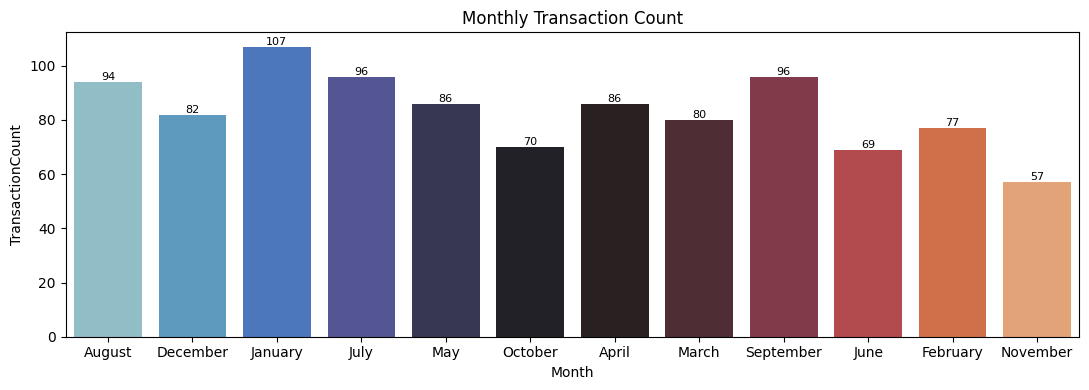

In [24]:
query = """ select monthname(TransactionDate) Month, count(CustomerID) from transactions
group by Month """

cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(data, columns=['Month', 'TransactionCount'])

plt.figure(figsize=(11,4))
ax = sns.barplot(df, x='Month', y='TransactionCount', palette='icefire')
plt.title('Monthly Transaction Count')

for container in ax.containers:
    ax.bar_label(container, size=8)

plt.tight_layout()
plt.show()    

### How does revenue compare between 2023 and 2024?

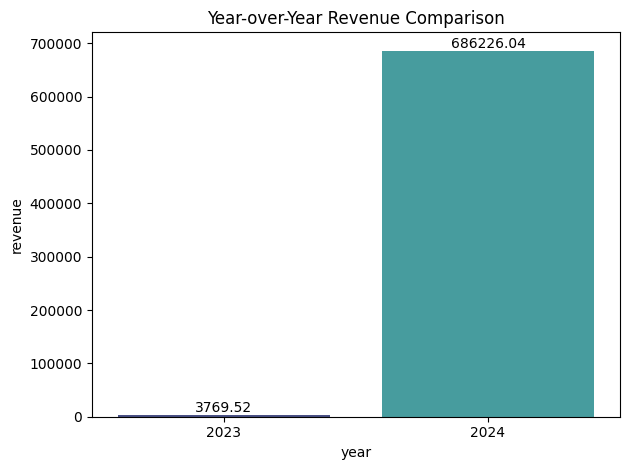

In [25]:
query = """ select year(TransactionDate) as year, round(sum(TotalValue), 2) as revenue
from transactions 
group by year
order by year
 """

cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(data, columns=['year', 'revenue'])

ax = sns.barplot(df, x='year', y='revenue', palette='mako')
plt.title('Year-over-Year Revenue Comparison')

for container in ax.containers:
    ax.bar_label(container, size=10, fmt='%.2f')

plt.tight_layout()
plt.show()    

### What is the quarterly revenue trend?

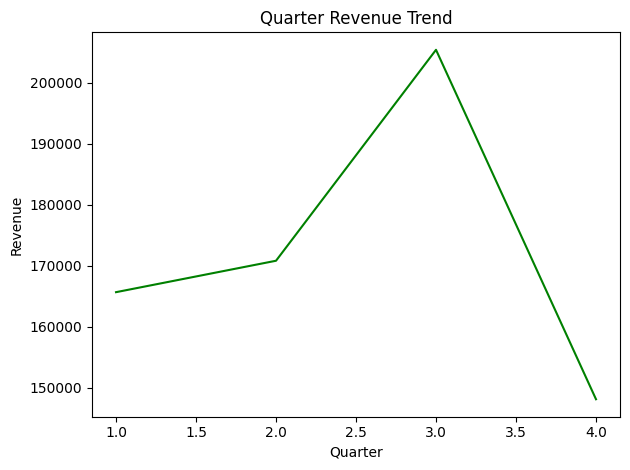

In [26]:
query = """ select quarter(TransactionDate) as quarter, round(sum(TotalValue), 2) as revenue
from transactions 
group by quarter
order by quarter
 """

cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(data, columns=['Quarter', 'Revenue'])

ax = sns.lineplot(df, x='Quarter', y='Revenue', color='g')
plt.title('Quarter Revenue Trend')

plt.tight_layout()
plt.show()  

### Which quarter generates the highest revenue?

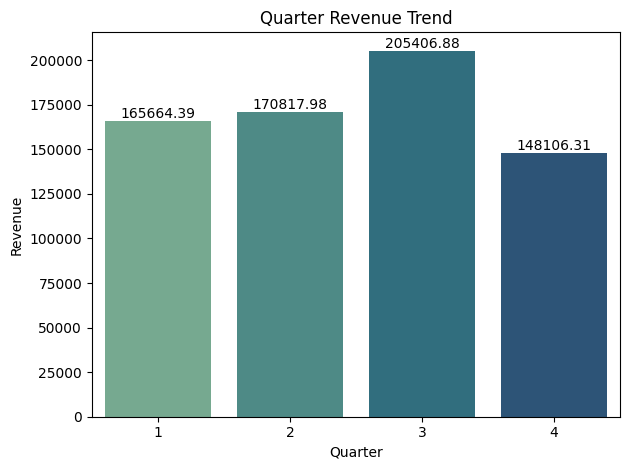

In [27]:
query = """ select quarter(TransactionDate) as quarter, round(sum(TotalValue), 2) as revenue
from transactions 
group by quarter
order by quarter
 """

cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(data, columns=['Quarter', 'Revenue'])

ax = sns.barplot(df, x='Quarter', y='Revenue', palette='crest')
plt.title('Quarter Revenue Trend')

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f')

plt.tight_layout()
plt.show() 

### Which Day of the week has the highest sales?

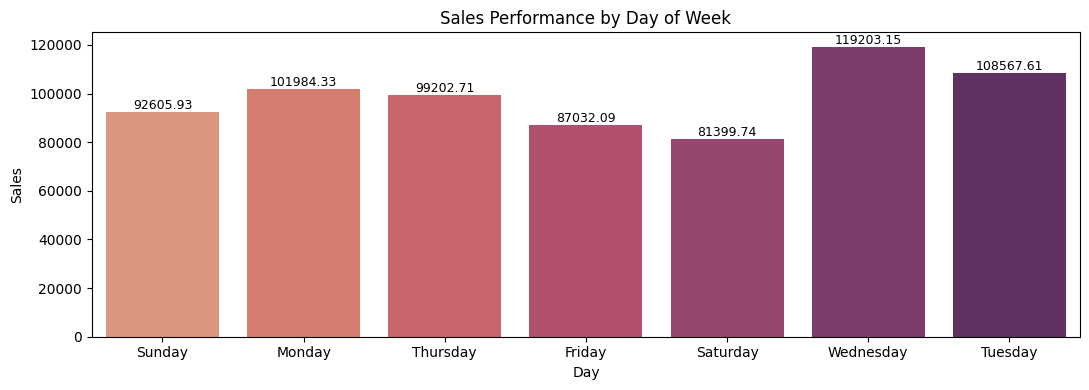

In [28]:
query = """ select dayname(TransactionDate) as Day, round(sum(TotalValue),2) as Sales
from transactions 
group by Day
"""

cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(data, columns=['Day', 'Sales'])

plt.figure(figsize=(11,4))
ax = sns.barplot(df, x='Day', y='Sales', palette='flare')
plt.title('Sales Performance by Day of Week')

for container in ax.containers:
    ax.bar_label(container, size=9, fmt='%.2f')

plt.tight_layout()
plt.show()    

### Is there a noticeable upward or downward trend in revenue over time?

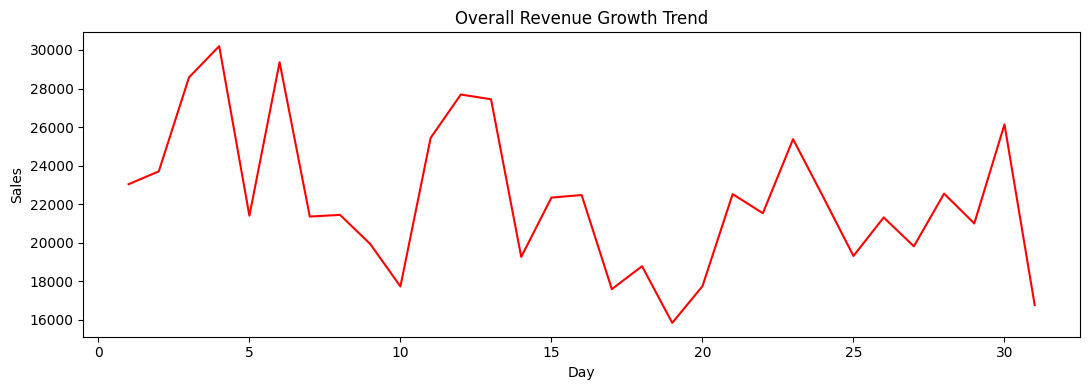

In [29]:
query = """ select day(TransactionDate) as Day, round(sum(TotalValue),2) as Sales
from transactions 
group by Day
"""

cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(data, columns=['Day', 'Sales'])

plt.figure(figsize=(11,4))
ax = sns.lineplot(df, x='Day', y='Sales', color='r')
plt.title('Overall Revenue Growth Trend')

plt.tight_layout()
plt.show()    

### How many customers have made only one purchase?

In [30]:
query = """ select c.CustomerName, count(t.CustomerID) as customer_count from transactions t
join customers c
on c.CustomerID = t.CustomerID
group by c.CustomerName 
having customer_count = 1
"""

cur.execute(query)

data = cur.fetchall()

"No customers have made only a single purchase here",data

('No customers have made only a single purchase here',
 [('Angela Williams', 1),
  ('Tina Ford', 1),
  ('Mr. Manuel Conway', 1),
  ('Amber Gonzalez', 1),
  ('Deborah Wilcox', 1),
  ('Elizabeth Wells', 1),
  ('James Murphy', 1),
  ('Robert Jones', 1),
  ('Tyler Holt', 1),
  ('Julia Palmer', 1),
  ('David Gonzalez', 1),
  ('Zachary Turner', 1)])

### What is the repeat purchase count per customer?

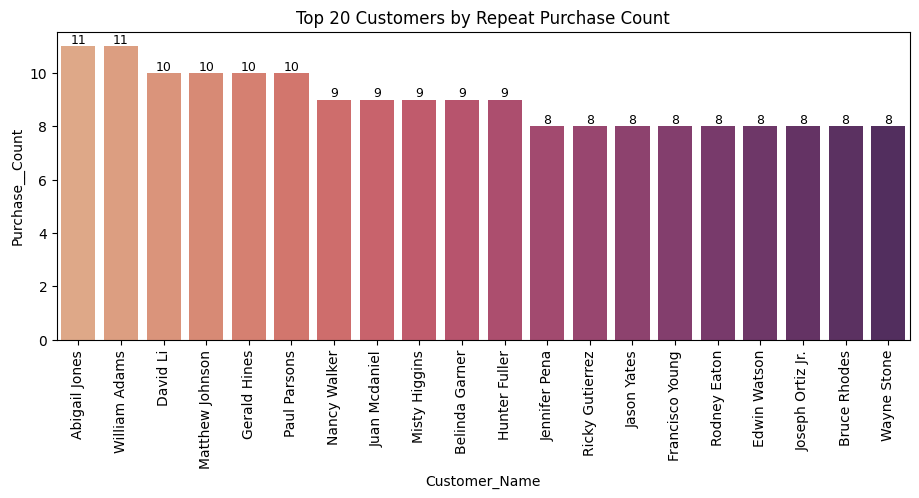

In [31]:
query = """ select c.CustomerName, count(t.TransactionID) as customer_count from transactions t
join customers c
on c.CustomerID = t.CustomerID
group by c.CustomerName 
order by customer_count desc
limit 20
"""

cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(data, columns=['Customer_Name', 'Purchase__Count'])

plt.figure(figsize=(11,4))
ax = sns.barplot(df, x='Customer_Name', y='Purchase__Count', palette='flare')
plt.title('Top 20 Customers by Repeat Purchase Count')
plt.xticks(rotation=90)

for container in ax.containers:
    ax.bar_label(container, size=9, fmt='%.f')


plt.show()    

### Who are the highest-value customers?

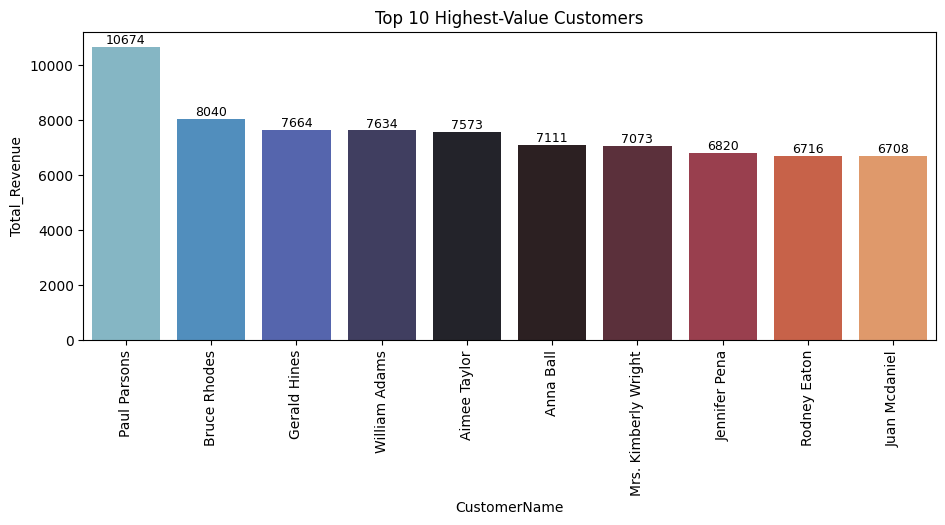

In [32]:
query = """ select c.CustomerName, round(sum(t.TotalValue), 2) as revenue from transactions t
join customers c
on c.CustomerID = t.CustomerID
group by CustomerName 
order by revenue desc
limit 10"""

cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(data, columns=['CustomerName', 'Total_Revenue'])

plt.figure(figsize=(11,4))
ax = sns.barplot(df, x='CustomerName', y='Total_Revenue', palette='icefire')
plt.title('Top 10 Highest-Value Customers')
plt.xticks(rotation=90)

for container in ax.containers:
    ax.bar_label(container, size=9, fmt='%.f')

plt.show()   

### What is the average number of transactions per customer?

In [33]:
query = """ with customer_transactions as (
select CustomerID, count(TransactionID) as transaction_count from transactions 
group by CustomerID
)
select round(avg(transaction_count),2) from customer_transactions"""

cur.execute(query)

data = cur.fetchall()

print(f"Average transaction per customer is :{data[0][0]}")

Average transaction per customer is :5.03


### What is the average quantity per transaction?

In [34]:
query = """ select round((sum(Quantity) / count(TransactionID)),2) from transactions"""

cur.execute(query)

data = cur.fetchall()

print(f"Average Quantity Per Transaction : {data[0][0]}")

Average Quantity Per Transaction : 2.54


### Is product price related to revenue?

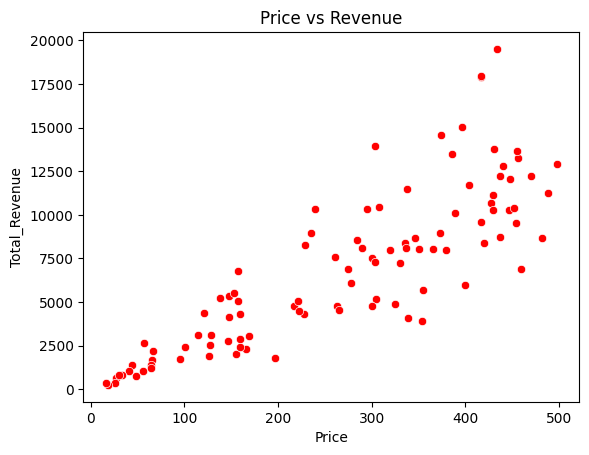

In [35]:
query = """ select p.ProductID, p.ProductName, p.Price, sum(t.TotalValue) as total_revenue
from products p
join transactions t
on p.ProductID = t.ProductID
group by p.ProductID, p.ProductName, p.Price """

cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(data, columns = ['ProductID', 'ProductName', 'Price', 'Total_Revenue'])

ax = sns.scatterplot(df, x='Price', y='Total_Revenue', color='r')
plt.title('Price vs Revenue')

plt.show()  

### Is sales Quantity related to revenue?

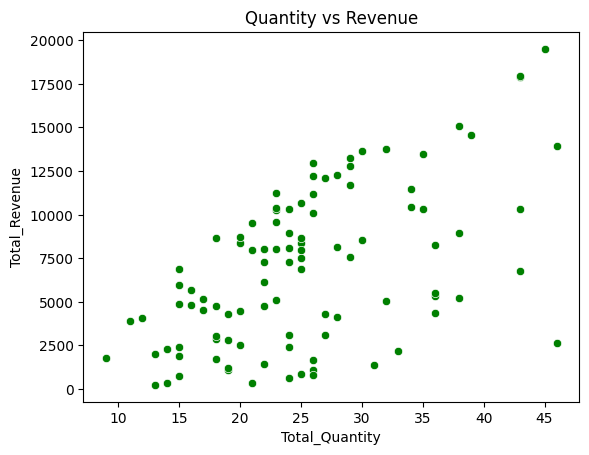

In [36]:
query = """ select ProductID, sum(Quantity), sum(TotalValue) as total_revenue
from transactions 
group by ProductID
"""

cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(data, columns = ['ProductID', 'Total_Quantity', 'Total_Revenue'])

ax = sns.scatterplot(df, x='Total_Quantity', y='Total_Revenue', color='g')
plt.title('Quantity vs Revenue')

plt.show()  